# Hydraulic Predictive Maintenance — Stage 2: Data Validation & Feature Engineering

**Client:** Bosch Rexroth AG · **Stage:** 2 of 7 · **Notebook:** `02_Data_Validation_and_Feature_Engineering.ipynb`
**Builds on:** Stage 1 EDA (confirmed) · **Code:** `src/pdm` package in this repository

---

## Purpose

Stage 1 showed *what* is wrong with the data and *where* the signal is. Stage 2 turns those findings into a **reproducible, tested pipeline** that converts the raw files into a model-ready dataset:

```
raw CSV ─► ingest (bronze) ─► validate + quarantine ─► clean (silver) ─► regime baseline ─► hourly features + targets (gold) ─► screening ─► folds
```

All logic lives in the `src/pdm` package, and all thresholds live in `configs/config.yaml`. This notebook calls the package step by step so every decision can be seen and checked, and the same code runs unchanged from the command line (`python -m pdm.pipeline`) and, in Stage 4, in CI/CD.

## How each Stage 1 finding is handled

| Stage 1 finding | Stage 2 treatment | Module |
|---|---|---|
| DQ-01 sensor dropouts (≤17 min) | Causal forward-fill ≤ 15 min + `was_imputed` flag | `data/clean.py` |
| DQ-02/03 pressure spikes, negative temperatures | Set NaN (never clipped), then filled; counted as a quality feature | `data/clean.py` |
| DQ-04 undocumented standby day | Detected automatically from rpm < 1,200; own regime; no health score | `data/clean.py`, `features/baseline.py` |
| DQ-05 vibration Y ≈ X | X−Y divergence features | `features/build.py` |
| DQ-07 flawed RUL target | Rebuilt: capped RUL, censoring, repair excluded | `features/targets.py` |
| DQ-09 schema drift | Executable data contract (pandera), renames, quarantine | `data/schemas.py`, `data/validate.py` |
| Label leakage (`is_anomaly`) | Label columns dropped before feature building | `data/clean.py` |
| Operating regimes (EDA §7) | Per machine × day type × hour healthy baseline | `features/baseline.py` |
| Machine-identity leak (EDA §9.2) | rpm excluded, identity-leak screen, leave-one-machine-out folds | `features/selection.py`, `features/splits.py` |

## Contents
1. Environment and project setup
2. Configuration
3. Ingestion (bronze)
4. Validation gate
5. Cleaning (silver)
6. Regime-aware healthy baseline
7. Target construction
8. Feature engineering (gold)
9. Feature screening and the identity-leak check
10. Validation folds
11. Persisted outputs
12. Summary and plan for Stage 3

## 1. Environment and project setup

**Google Colab:** upload the whole project folder `bosch_rexroth_pdm/` to Google Drive (for example `MyDrive/bosch_rexroth_pdm/`), put the three CSVs in `data/raw/`, and run the cell below. It mounts Drive, installs the dependencies and the `pdm` package, and switches into the project folder.
Locally, the cell just locates the project root (the parent of `notebooks/`).

In [1]:
import os, sys, subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/bosch_rexroth_pdm")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(PROJECT_DIR / "requirements.txt")], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(PROJECT_DIR)], check=True)
else:
    PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR / "src"))     # makes `import pdm` work even without a runtime restart
print("Project root:", PROJECT_DIR)
print("Raw files   :", sorted(p.name for p in (PROJECT_DIR / "data" / "raw").glob("*.csv")))

Project root: /home/claude/bosch_rexroth_pdm
Raw files   : ['failure_labels.csv', 'maintenance_log.csv', 'sensor_telemetry.csv']


In [2]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import pdm
from pdm.config import load_config
from pdm.data.ingest import ingest
from pdm.data.validate import validate_all
from pdm.data.clean import clean_telemetry
from pdm.features.baseline import RegimeBaseline
from pdm.features.targets import build_targets
from pdm.features.build import build_features
from pdm.features.selection import (select_features, eligible_rows, identity_chance_level,
                                    multi_feature_identity_accuracy)
from pdm.features.splits import leave_one_machine_out, assign_folds

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
print("pdm package version:", pdm.__version__, "| pandas", pd.__version__)

MODES = ["pump_wear", "valve_leakage", "contamination", "cylinder_drift"]
COLORS = {"healthy": "#9a9892", "pump_wear": "#2a78d6", "valve_leakage": "#eb6834",
          "contamination": "#1baf7a", "cylinder_drift": "#4a3aa7", "accent": "#e34948"}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "semibold", "axes.titlesize": 12,
                     "axes.spines.top": False, "axes.spines.right": False, "grid.color": "#e6e5e0",
                     "axes.edgecolor": "#b5b3ab", "lines.linewidth": 1.8, "legend.frameon": False})
FIG_DIR = Path("reports/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
save = lambda fig, name: fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", dpi=150)

pdm package version: 0.2.0 | pandas 2.2.2


### 1.1 Quality gate: run the unit tests first

Before the pipeline touches real data, the test suite checks every rule on small synthetic data (27 tests, a few seconds). The most important one is `test_no_look_ahead`. It changes all readings after a cut-off time and asserts that **no feature before the cut-off changes**, which proves the features do not use future information. The same command will run automatically on every commit in Stage 4.

In [3]:
r = subprocess.run([sys.executable, "-m", "pytest", "--color=no", "-p", "no:cacheprovider", "-rA"], capture_output=True, text=True)
print("\n".join(l for l in r.stdout.splitlines() if l.startswith(("PASSED", "FAILED", "ERROR")) or " passed" in l or " failed" in l))
assert r.returncode == 0, "Unit tests failed: fix before running the pipeline"

PASSED tests/test_baseline.py::test_baseline_ignores_data_after_reference_period
PASSED tests/test_baseline.py::test_regime_offsets_are_removed
PASSED tests/test_baseline.py::test_standby_rows_get_no_health_score
PASSED tests/test_baseline.py::test_save_and_load_round_trip
PASSED tests/test_clean.py::test_impossible_values_are_removed_then_filled_and_flagged
PASSED tests/test_clean.py::test_only_the_first_n_minutes_of_a_long_gap_are_filled
PASSED tests/test_clean.py::test_missing_timestamps_become_explicit_rows
PASSED tests/test_clean.py::test_regime_tagging_matches_shift_boundaries_and_detects_standby
PASSED tests/test_clean.py::test_label_columns_are_dropped_and_regimes_agree_with_source
PASSED tests/test_features.py::test_row_T_summarises_the_previous_hour
PASSED tests/test_features.py::test_no_look_ahead
PASSED tests/test_features.py::test_rolling_slope_recovers_a_linear_trend
PASSED tests/test_features.py::test_spectral_features_locate_a_periodic_signal
PASSED tests/test_features.

## 2. Configuration

Every threshold used below comes from `configs/config.yaml`, with a comment tracing it to the EDA. Changing a rule is a reviewed, versioned edit to that file, not a change to notebook code.

In [4]:
cfg = load_config("configs/config.yaml")
show = {k: cfg[k] for k in ["cleaning", "regimes", "baseline", "targets"]}
print(json.dumps(show, indent=2, default=str))

{
  "cleaning": {
    "valid_ranges": {
      "pressure_bar": [
        0,
        350
      ],
      "temp_celsius": [
        10,
        90
      ],
      "flow_lpm": [
        0,
        150
      ],
      "vibration_x_g": [
        0,
        16
      ],
      "vibration_y_g": [
        0,
        16
      ],
      "pump_rpm": [
        500,
        1600
      ]
    },
    "max_interpolation_gap_min": 15
  },
  "regimes": {
    "standby_rpm_below": 1200,
    "day_shift_hours": [
      8,
      20
    ],
    "weekend_days": [
      5,
      6
    ],
    "midnight_dip_hours": [
      0
    ]
  },
  "baseline": {
    "reference_days": 14,
    "min_samples_per_cell": 20,
    "signals": [
      "pressure_bar",
      "temp_celsius",
      "flow_lpm",
      "vibration_x_g",
      "vibration_y_g"
    ]
  },
  "targets": {
    "rul_cap_hours": 336,
    "warning_horizon_hours": 168
  }
}


## 3. Ingestion (bronze layer)

Raw files are read with **explicit types** and mapped to the data contract (`failure_event_id → event_id`, `maintenance_id → action_id`). The literal string `"None"` in `component_replaced` is kept as a category rather than parsed as missing. Values are not changed here, so every later change can be traced back to the raw data. Output: `data/interim/bronze_*.parquet`.

In [5]:
tables = ingest(cfg)
for name, df in tables.items():
    print(f"{name:<12} {df.shape}  columns: {list(df.columns)[:8]}{' …' if df.shape[1] > 8 else ''}")

telemetry    (864000, 14)  columns: ['timestamp', 'machine_id', 'pressure_bar', 'temp_celsius', 'flow_lpm', 'vibration_x_g', 'vibration_y_g', 'pump_rpm'] …
failures     (9, 7)  columns: ['event_id', 'machine_id', 'failure_timestamp', 'failure_mode', 'degradation_start_timestamp', 'repair_cost_usd', 'downtime_hours']
maintenance  (51, 7)  columns: ['action_id', 'machine_id', 'action_timestamp', 'action_type', 'component_replaced', 'technician_id', 'cost_usd']


## 4. Validation gate

The data contract is enforced as **pandera schemas** (`src/pdm/data/schemas.py`). Every check has one of three outcomes:

| Outcome | When | Effect |
|---|---|---|
| **reject** | structural failure (for example a required column is missing) | the whole batch stops; nothing downstream runs |
| **quarantine** | a row breaks a hard rule (bad key, unknown category, duplicate) | the row is removed and written to `data/quarantine/` with the reason |
| **warn** | a soft rule (sensor range, sampling gap, sensor floor) | the row is kept; the cleaning step handles it; the count is reported |

In [6]:
valid, report, quarantine = validate_all(tables, cfg)
print("Validation passed:", report.passed)
print("Rows in :", report.rows_in); print("Rows out:", report.rows_out)
report.to_frame()

Validation passed: True
Rows in : {'telemetry': 864000, 'failures': 9, 'maintenance': 51}
Rows out: {'telemetry': 864000, 'failures': 9, 'maintenance': 51}


,table,check,severity,n_failed,action,detail
0,telemetry,"unique (machine_id, timestamp)",info,0,pass,
1,telemetry,contract schema,info,0,pass,
2,telemetry,"pressure_bar within [0, 350]",warning,250,set NaN in cleaning,
3,telemetry,"temp_celsius within [10, 90]",warning,170,set NaN in cleaning,
4,telemetry,"flow_lpm within [0, 150]",info,0,pass,
5,telemetry,"vibration_x_g within [0, 16]",info,0,pass,
6,telemetry,"vibration_y_g within [0, 16]",info,0,pass,
7,telemetry,"pump_rpm within [500, 1600]",info,0,pass,
8,telemetry,vibration_x_g readings exactly at sensor floor...,warning,206697,keep; exclude floor-driven minima from features,23.9% of rows
9,telemetry,vibration_y_g readings exactly at sensor floor...,warning,209734,keep; exclude floor-driven minima from features,24.3% of rows


**Findings: validation**

- The batch **passes the contract**. No rows needed quarantine: keys are unique, categories are valid, and failure events are internally consistent.
- The known soft issues are counted and passed on to cleaning: 250 pressure spikes and 170 negative temperatures.
- **New finding (DQ-10): the vibration sensors are floor-clipped.** About **24% of all vibration readings are exactly 0.05 g**, the lowest value the sensor reports. The *low* end of the vibration distribution is therefore not real information, and features built on vibration **minima** would only describe the clip level. We use them nowhere (see §9).
- Confirmed again: the maintenance log has **no events inside the telemetry period** (DQ-08).
- The full report is saved as `reports/validation_report.md` and `.json`, for the data owner and for CI in Stage 4.

## 5. Cleaning (silver layer)

Rules applied (`src/pdm/data/clean.py`):
1. Reindex every machine onto a complete 1-minute grid.
2. Physically impossible values → NaN (never clipped).
3. **Causal forward-fill** of at most 15 minutes, flagged `was_imputed`. We do *not* linearly interpolate, because interpolation uses the next valid reading, up to 15 minutes in the future. That value is not available to a live inference service, so it would make offline results look better than production.
4. Tag each minute with its operating **regime**. Standby is detected **from the data** (rpm < 1,200), not hard-coded to 15 Jan, so a future standby day is handled automatically.
5. Drop label columns (`is_anomaly`, `failure_mode`, `rul_hours`).

In [7]:
silver, clean_log = clean_telemetry(valid["telemetry"], cfg)
print(json.dumps(clean_log, indent=2, default=str))

{
  "rows_in": 864000,
  "rows_added_by_reindex": 0,
  "missing_values_before": 15540,
  "values_invalidated": {
    "pressure_bar": 250,
    "temp_celsius": 170,
    "flow_lpm": 0,
    "vibration_x_g": 0,
    "vibration_y_g": 0,
    "pump_rpm": 0
  },
  "rows_imputed": 3008,
  "missing_values_after": 12,
  "regime_minutes": {
    "Night": 309600,
    "Day": 309600,
    "Weekend": 230400,
    "Standby": 14400
  },
  "standby_days": [
    "2024-01-15"
  ],
  "regime_vs_source_shift_agreement": 1.0,
  "rows_out": 864000
}


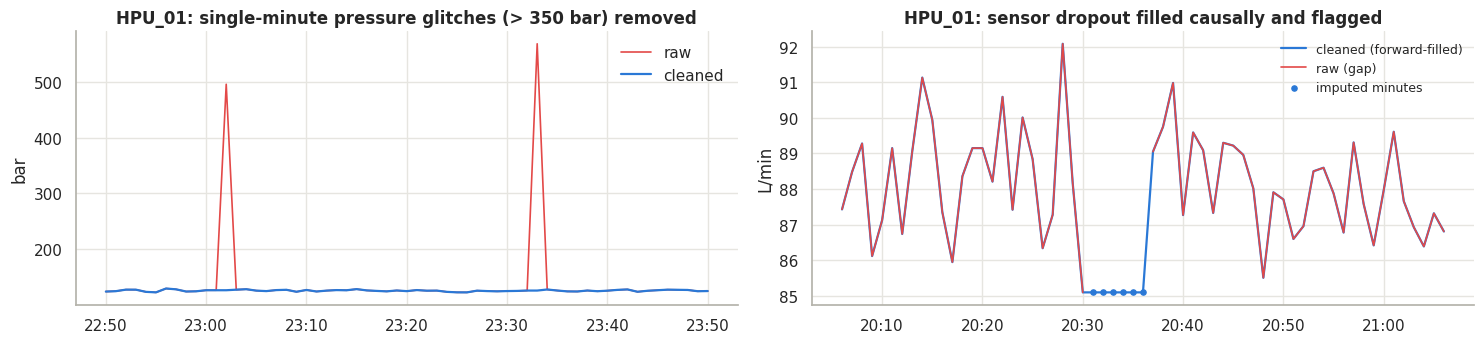

In [8]:
raw = valid["telemetry"]
fig, axes = plt.subplots(1, 2, figsize=(15, 3.6))
# (a) a pressure glitch
m, t0, t1 = "HPU_01", "2024-01-12 22:50", "2024-01-12 23:50"
r_ = raw[(raw.machine_id == m) & raw.timestamp.between(t0, t1)]
s_ = silver[(silver.machine_id == m) & silver.timestamp.between(t0, t1)]
axes[0].plot(r_.timestamp, r_.pressure_bar, color=COLORS["accent"], lw=1.2, label="raw")
axes[0].plot(s_.timestamp, s_.pressure_bar, color=COLORS["pump_wear"], lw=1.6, label="cleaned")
axes[0].set(title=f"{m}: single-minute pressure glitches (> 350 bar) removed", ylabel="bar"); axes[0].legend()
# (b) a dropout
ep = raw[raw.is_sensor_dropout == 1].iloc[0]
w0, w1 = ep.timestamp - pd.Timedelta("25min"), ep.timestamp + pd.Timedelta("35min")
r_ = raw[(raw.machine_id == ep.machine_id) & raw.timestamp.between(w0, w1)]
s_ = silver[(silver.machine_id == ep.machine_id) & silver.timestamp.between(w0, w1)]
axes[1].plot(s_.timestamp, s_.flow_lpm, color=COLORS["pump_wear"], lw=1.6, label="cleaned (forward-filled)")
axes[1].plot(r_.timestamp, r_.flow_lpm, color=COLORS["accent"], lw=1.2, label="raw (gap)")
imp = s_[s_.was_imputed]
axes[1].scatter(imp.timestamp, imp.flow_lpm, s=14, color=COLORS["pump_wear"], zorder=3, label="imputed minutes")
axes[1].set(title=f"{ep.machine_id}: sensor dropout filled causally and flagged", ylabel="L/min"); axes[1].legend(fontsize=9)
for ax in axes: ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout(); save(fig, "s2_cleaning_examples"); plt.show()

**Findings: cleaning**

- 420 impossible readings were removed and about 3,000 minutes were forward-filled. After cleaning, **only 12 sensor values remain missing**, in the tails of the few dropouts longer than 15 minutes. These are left as NaN on purpose.
- Our regime tagging agrees **100% with the source `shift` column** on all non-standby minutes, which is an independent check of the rule. Standby was detected on exactly one day (15 Jan) with no hard-coded date.

## 6. Regime-aware healthy baseline

Each machine's "normal" is learned per **day type (Weekday / Weekend) × hour of day** from its **own first 14 days**, with standby excluded. Readings are then expressed as z-scores and % deviations from that baseline. This is the normalisation that removed the false alarms in the EDA (§8.3).

Why the first 14 days? No labelled degradation starts before 21 Jan, and a real deployment would use a commissioning period in the same way. Consequence: **a new machine needs 14 days of history before it can be scored** (the cold-start requirement). The fitted baseline is saved (`data/processed/regime_baseline.parquet`) because inference must use exactly the same "normal".

In [9]:
bl = RegimeBaseline(cfg["baseline"]["signals"], cfg["baseline"]["reference_days"], cfg["baseline"]["min_samples_per_cell"])
silver_z = bl.fit_transform(silver)
print("Baseline cells:", len(bl.table_), "(10 machines × 2 day types × 24 hours)")
display(bl.table_.loc["HPU_10"].xs("Weekday", level=0)[["pressure_bar__median", "pressure_bar__std", "flow_lpm__median", "temp_celsius__median"]]
          .iloc[[0, 1, 7, 8, 12, 19, 20, 23]].round(2))

Baseline cells: 480 (10 machines × 2 day types × 24 hours)


,pressure_bar__median,pressure_bar__std,flow_lpm__median,temp_celsius__median
hour,,,,
0,121.52,4.74,87.90,51.21
1,125.98,1.58,88.06,51.68
7,125.82,1.57,87.98,51.65
8,137.93,1.81,96.10,52.84
12,137.84,1.81,96.02,52.84
19,138.05,1.73,96.29,52.86
20,125.92,1.58,87.85,51.63
23,125.97,1.54,88.06,51.67


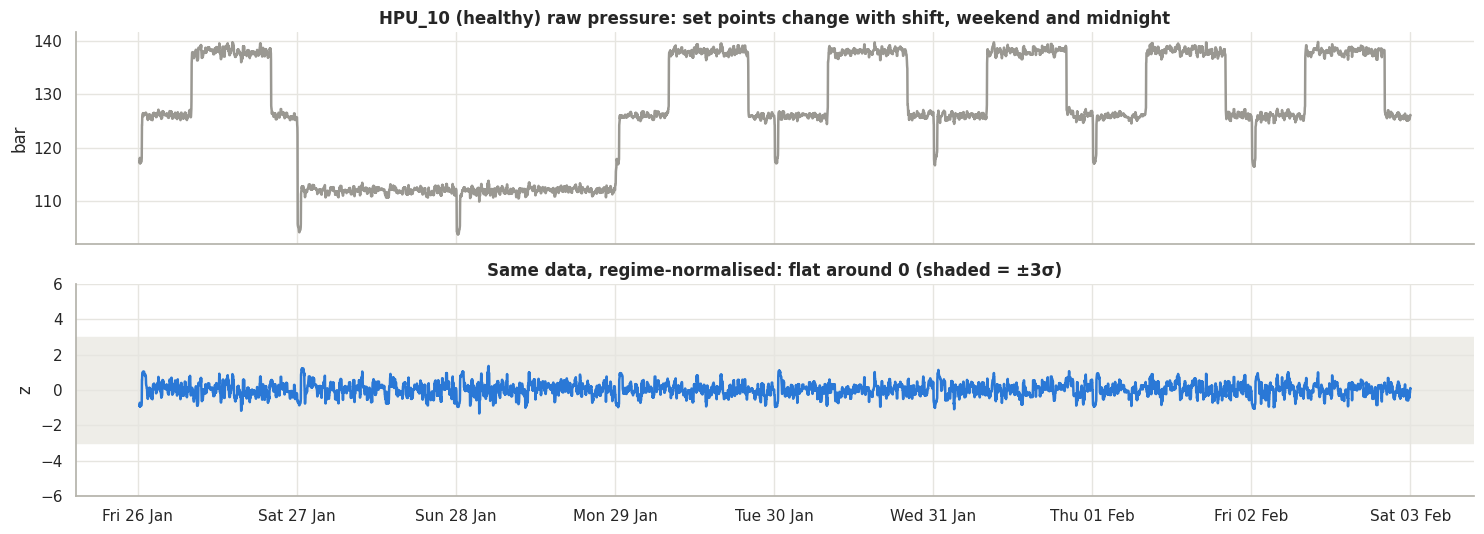

In [10]:
wk = silver_z[(silver_z.machine_id == "HPU_10") & silver_z.timestamp.between("2024-01-26", "2024-02-03")].set_index("timestamp")
fig, axes = plt.subplots(2, 1, figsize=(15, 5.5), sharex=True)
axes[0].plot(wk.index, wk.pressure_bar.rolling(15).median(), color=COLORS["healthy"])
axes[0].set(title="HPU_10 (healthy) raw pressure: set points change with shift, weekend and midnight", ylabel="bar")
axes[1].plot(wk.index, wk.z_pressure_bar.rolling(15).median(), color=COLORS["pump_wear"])
axes[1].axhspan(-3, 3, color="#eeede8", zorder=0)
axes[1].set(title="Same data, regime-normalised: flat around 0 (shaded = ±3σ)", ylabel="z", ylim=(-6, 6))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
plt.tight_layout(); save(fig, "s2_regime_normalisation"); plt.show()

### 6.1 New finding: a slow fleet-wide temperature drift (DQ-11)

When we check whether healthy machines stay at z ≈ 0 over the whole period, oil temperature does **not**. It creeps upwards on *every* machine at the same time.

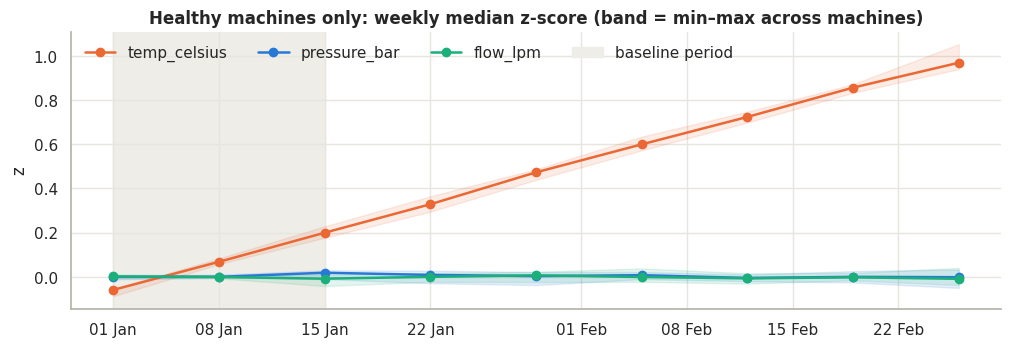

In [11]:
hz = silver_z[~silver_z.is_standby].copy()
fail = valid["failures"]
deg = hz.merge(fail[["machine_id", "degradation_start_timestamp", "failure_timestamp"]], on="machine_id", how="left")
healthy_mask = ~((deg.timestamp >= deg.degradation_start_timestamp) & (deg.timestamp < deg.failure_timestamp + pd.Timedelta("1D"))).fillna(False)
weekly = (deg[healthy_mask.values].set_index("timestamp").groupby("machine_id")[["z_temp_celsius", "z_pressure_bar", "z_flow_lpm"]]
          .resample("7D").median().groupby(level=1).agg(["median", "min", "max"]))
fig, ax = plt.subplots(figsize=(12, 3.6))
for col, c in [("z_temp_celsius", COLORS["valve_leakage"]), ("z_pressure_bar", COLORS["pump_wear"]), ("z_flow_lpm", COLORS["contamination"])]:
    ax.plot(weekly.index, weekly[(col, "median")], marker="o", color=c, label=col.replace("z_", ""))
    ax.fill_between(weekly.index, weekly[(col, "min")], weekly[(col, "max")], color=c, alpha=0.12)
ax.axvspan(pd.Timestamp("2024-01-01"), pd.Timestamp("2024-01-15"), color="#eeede8", zorder=0, label="baseline period")
ax.set(title="Healthy machines only: weekly median z-score (band = min–max across machines)", ylabel="z")
ax.legend(ncol=4, loc="upper left"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
save(fig, "s2_temperature_drift"); plt.show()

**Finding (DQ-11): fleet-wide temperature drift.** Healthy machines' oil temperature rises **almost perfectly linearly by about +1σ (≈ +0.5–1 °C) over eight weeks, on every machine together**. The min–max band across machines is very narrow. Pressure and flow stay flat. The most likely causes are seasonal ambient temperature or gradual oil ageing across the fleet. Why it matters:

1. A model trained on January would slowly see more "hot" readings. For valve leakage, which is detected via temperature, this could cause false alarms by summer. **This is exactly the drift Stage 7 monitoring must watch.**
2. **Mitigation built into Stage 2:** *fleet-relative* features, which subtract the fleet median at the same hour. They cancel anything that affects all machines at once, while a single degrading machine still stands out.
3. Longer term: refresh baselines on a rolling window of confirmed-healthy data.

## 7. Target construction

Targets are rebuilt from `failure_labels.csv` (DQ-07). The supplied `rul_hours` column is never used. Each hourly row `T` summarises the minutes `[T − 1h, T)`.

| Target | Definition | Used for |
|---|---|---|
| `failure_mode_label` | mode of the next failure if T is inside its degradation window, else `healthy` (`repair` during downtime) | classification |
| `rul_hours` | `min(next failure − T, 336 h)`; right-censored when no failure is observed (see below) | RUL regression |
| `fail_within_h` | 1 if a failure occurs within 168 h (7 days) | early-warning alert |
| `in_repair` | window overlaps `[failure, failure + downtime_hours)` | excluded from training |
| `life_cycle` | number of failures before T; each repair starts a new cycle | grouping, analysis |

**Censoring.** For HPU_10, or any machine after its repair, no future failure is observed. We only know RUL ≥ time left in the data. If that lower bound already exceeds the 336 h cap, the capped RUL is known exactly (= 336 h). Otherwise RUL is unknown and those rows are excluded from regression. This keeps about 1,900 eligible healthy hours with an exactly known (capped) RUL that a naive approach would throw away, without inventing labels.

In [12]:
feats_index = silver_z.assign(T=silver_z.timestamp.dt.floor("1h") + pd.Timedelta("1h"))[["machine_id", "T"]].drop_duplicates().rename(columns={"T": "timestamp"})
data_end = silver.groupby("machine_id")["timestamp"].max() + pd.Timedelta("1min")
targets = build_targets(feats_index, valid["failures"], cfg, data_end=data_end)
print(targets["failure_mode_label"].value_counts().to_string())
print(f"\nRUL known: {targets.rul_hours.notna().sum():,} rows | censored (unknown): {targets.rul_censored.sum():,} | in repair: {targets.in_repair.sum():,}")

failure_mode_label
healthy           12176
pump_wear           960
valve_leakage       720
contamination       240
cylinder_drift      192
repair              112

RUL known: 11,680 rows | censored (unknown): 2,664 | in repair: 112


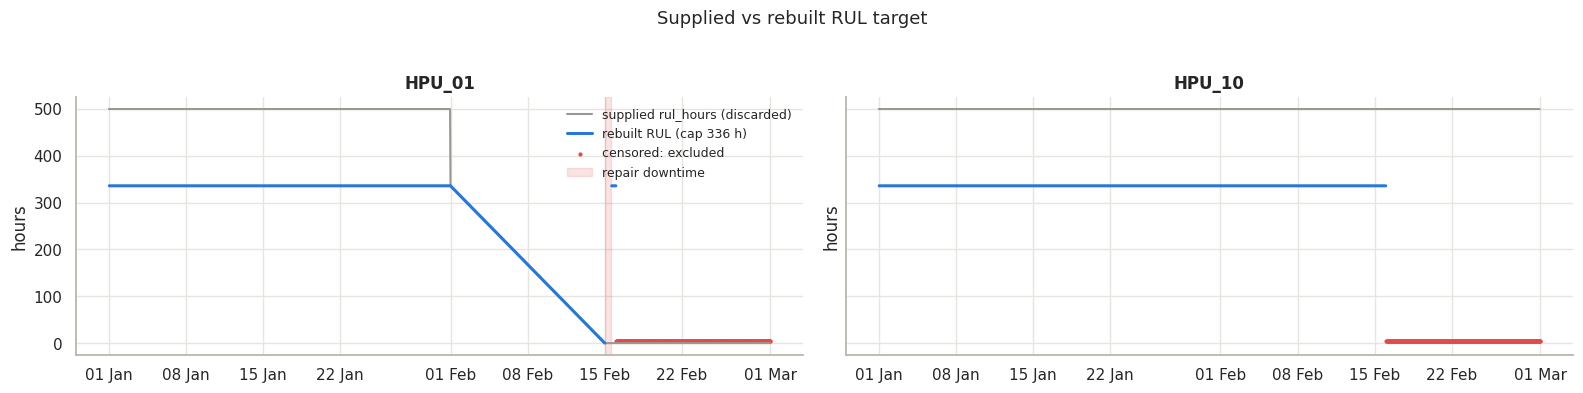

In [13]:
supplied = valid["telemetry"].set_index("timestamp")
fig, axes = plt.subplots(1, 2, figsize=(16, 3.8), sharey=True)
for ax, m in zip(axes, ["HPU_01", "HPU_10"]):
    s_ = supplied[supplied.machine_id == m]["rul_hours"].resample("1h").last()
    t_ = targets[targets.machine_id == m].set_index("timestamp")
    ax.plot(s_.index, s_, color=COLORS["healthy"], lw=1.5, label="supplied rul_hours (discarded)")
    ax.plot(t_.index, t_.rul_hours, color=COLORS["pump_wear"], lw=2.2, label="rebuilt RUL (cap 336 h)")
    cz = t_[t_.rul_censored]
    ax.scatter(cz.index, np.full(len(cz), 5), s=4, color=COLORS["accent"], label="censored: excluded")
    rp = t_[t_.in_repair]
    if len(rp): ax.axvspan(rp.index.min(), rp.index.max(), color=COLORS["accent"], alpha=0.15, label="repair downtime")
    ax.set(title=f"{m}", ylabel="hours"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
axes[0].legend(fontsize=9, loc="upper right")
fig.suptitle("Supplied vs rebuilt RUL target", y=1.03, fontsize=13)
plt.tight_layout(); save(fig, "s2_rul_rebuilt"); plt.show()

**Findings: targets**

- HPU_01: the rebuilt RUL decreases **continuously** from the 336 h cap to 0 at failure, with no 500 → 336 jump. After the repair, the misleading two weeks of zeros are gone. The first hours of the new life cycle are labelled 336 h and the rest are marked censored, because the data ends less than 14 days after the repair.
- HPU_10: RUL = 336 h (exactly known) until the last 14 days of data, after which it is honestly marked **censored** and excluded from regression.

## 8. Feature engineering (gold layer)

Features are built at **hourly** grain, which gives 14,400 rows instead of 864,000. Each row uses only data **before** its timestamp. The groups below come directly from the EDA findings:

| Group | Examples | Why (EDA) |
|---|---|---|
| `hourly_regime` | z / % deviation of pressure, temp, flow, vibration | regime normalisation, §8.1 |
| `fleet_relative` | z minus fleet median at the same hour | fleet-wide drift, DQ-11 |
| `cross_sensor` | X−Y divergence, pressure-vs-flow deviation, within-hour correlations | cylinder drift, §8.4; decoupling, §9.1 |
| `vibration` | p95, kurtosis, crest factor, burst count | contamination bursts, §5 |
| `rolling` | 6/24/72 h mean, std, min, max, **slope** | gradual degradation, §8.1 |
| `lag` | 1 h / 24 h lag and change | rate of change |
| `spectral` | FFT band shares and entropy of trailing 6 h vibration | burstiness (1-min data cannot resolve mechanical frequencies) |
| `context`, `quality` | hour (cyclic), weekend, imputed share, invalid count | regime context, data trust |
| `maintenance` | days since maintenance, reactive actions in 90 days | built but **excluded** (DQ-08) |

In [14]:
features, dictionary = build_features(silver_z, valid["maintenance"], cfg)
ds = features.merge(targets, on=["machine_id", "timestamp"], how="left")
print("Feature table:", features.shape, "| candidate features:", len(dictionary))
display(dictionary.groupby("group").size().rename("candidates").to_frame().T)
dictionary.sample(8, random_state=1)

Feature table: (14400, 250) | candidate features: 246


group,context,cross_sensor,fleet_relative,hourly_raw,hourly_regime,lag,maintenance,quality,rolling,spectral,vibration
candidates,5,7,4,24,20,20,3,4,150,5,4


,feature,group,description
67,z_pressure_bar_mean_roll6h_max,rolling,trailing 6 h max of z_pressure_bar_mean
245,reactive_actions_90d,maintenance,reactive actions in the previous 90 days
208,corr_pressure_flow_roll24h_slope,rolling,trailing 24 h slope of corr_pressure_flow (per...
222,z_flow_lpm_mean_lag1h,lag,z_flow_lpm_mean 1 h earlier
90,z_temp_celsius_mean_roll72h_std,rolling,trailing 72 h std of z_temp_celsius_mean
220,z_temp_celsius_mean_lag24h,lag,z_temp_celsius_mean 24 h earlier
58,standby_share,context,share of minutes in standby (rpm < threshold)
127,z_vibration_x_g_mean_roll6h_max,rolling,trailing 6 h max of z_vibration_x_g_mean


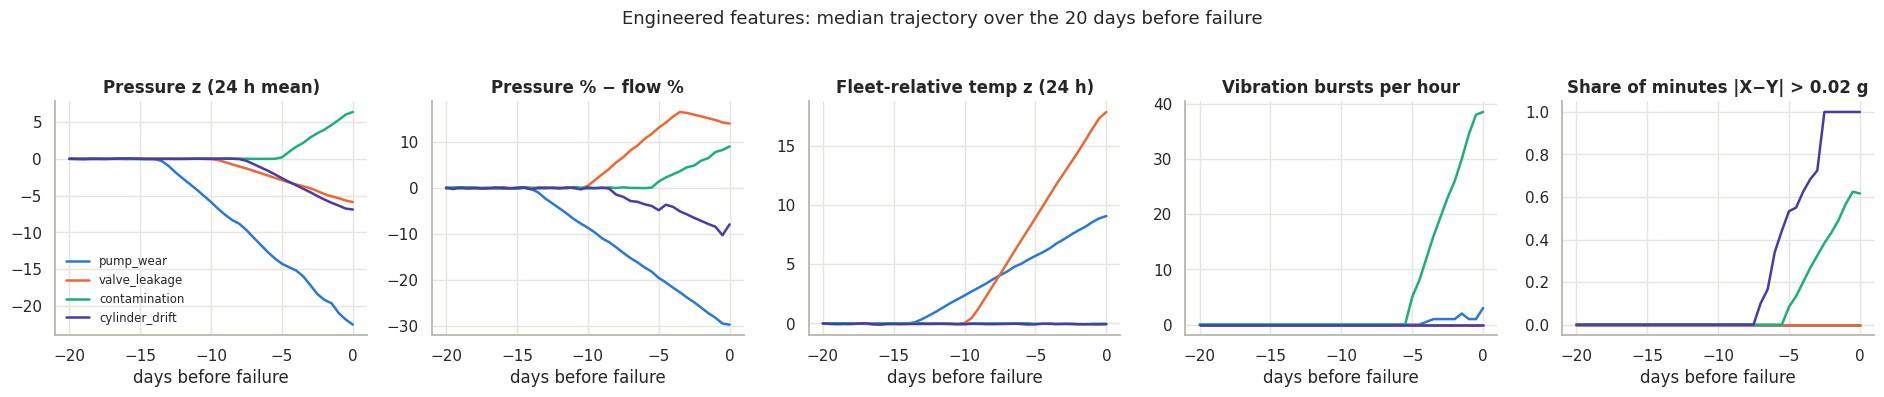

In [15]:
# How do a few engineered features evolve before each failure? (median across machines with the same mode)
show = [("z_pressure_bar_mean_roll24h_mean", "Pressure z (24 h mean)", "pump_wear"),
        ("pct_pressure_minus_flow_mean", "Pressure % − flow %", None),
        ("fz_temp_celsius_mean_roll24h_mean", "Fleet-relative temp z (24 h)", "valve_leakage"),
        ("vib_x_burst_count", "Vibration bursts per hour", "contamination"),
        ("xy_divergence_share", "Share of minutes |X−Y| > 0.02 g", "cylinder_drift")]
pre = ds[ds.hours_to_failure.between(0, 20 * 24)].copy()
pre["mode"] = pre.machine_id.map(valid["failures"].set_index("machine_id").failure_mode)
pre["days_before"] = -np.ceil(pre.hours_to_failure / 12) / 2
fig, axes = plt.subplots(1, len(show), figsize=(19, 3.8), sharex=True)
for ax, (col, title, _) in zip(axes, show):
    tr = pre.groupby(["mode", "days_before"])[col].median()
    for mode in MODES:
        ax.plot(tr.loc[mode].index, tr.loc[mode].values, color=COLORS[mode], label=mode)
    ax.set(title=title, xlabel="days before failure")
axes[0].legend(fontsize=8.5, loc="lower left")
fig.suptitle("Engineered features: median trajectory over the 20 days before failure", y=1.04, fontsize=13)
plt.tight_layout(); save(fig, "s2_feature_trajectories"); plt.show()

**Finding.** Each failure mode now has a distinctive **combination** of engineered features:

- **Pump wear:** the steepest pressure fall and a strongly negative pressure-minus-flow deviation.
- **Valve leakage:** the opposite sign on pressure-minus-flow, plus the fastest fleet-relative temperature rise.
- **Contamination:** the only mode with vibration bursts, and pressure rising rather than falling.
- **Cylinder drift:** the only mode where X−Y divergence appears together with a falling pressure. Contamination diverges only late, together with bursts.

This is the separability the classifier needs, and it is now expressed in features that can be computed live.

## 9. Feature screening and the identity-leak check

Screening is applied in order: excluded by config → mostly missing (> 50%) → constant → **identity leak** → redundancy (|r| > 0.98, keeping the most interpretable group first).

**Identity-leak check.** Each machine has exactly one failure mode, so any feature that reveals *which machine* a row came from also reveals the label without saying anything about wear. For every candidate feature we train a small decision tree to predict `machine_id` from that feature alone. It is trained on healthy hours before 21 Jan and tested on healthy hours after. Chance level is about 0.13.

In [16]:
ds["eligible"] = eligible_rows(ds)
selected, screening = select_features(ds, dictionary, cfg)
dictionary = dictionary.merge(screening.drop(columns="group"), on="feature", how="left")
print(f"Selected {len(selected)} of {len(dictionary)} candidate features")
display(dictionary.pivot_table(index="group", columns="status", values="feature", aggfunc="count", fill_value=0))

Selected 171 of 246 candidate features


status,dropped_constant,dropped_correlated,excluded_by_config,kept
group,,,,
context,1,0,0,3
cross_sensor,0,0,0,7
fleet_relative,0,0,0,4
hourly_raw,0,10,6,8
hourly_regime,0,16,2,2
lag,0,3,0,17
maintenance,0,0,3,0
quality,0,0,0,3
rolling,0,32,0,118


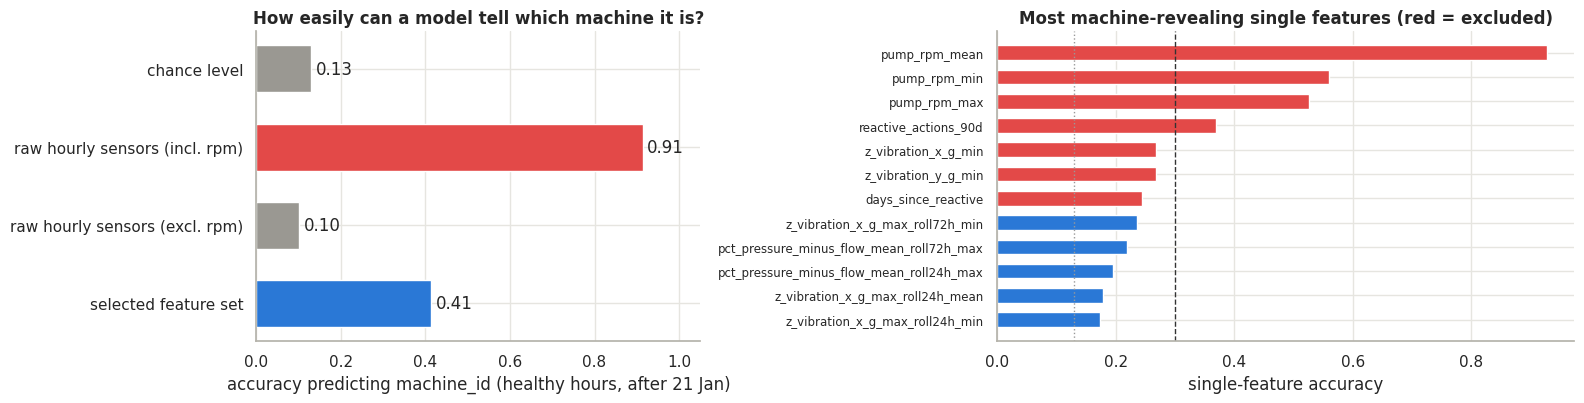

,feature,group,status,machine_id_accuracy
20,pump_rpm_mean,hourly_raw,excluded_by_config,0.927
22,pump_rpm_min,hourly_raw,excluded_by_config,0.559
23,pump_rpm_max,hourly_raw,excluded_by_config,0.527
245,reactive_actions_90d,maintenance,excluded_by_config,0.370
37,z_vibration_x_g_min,hourly_regime,excluded_by_config,0.268
41,z_vibration_y_g_min,hourly_regime,excluded_by_config,0.267
244,days_since_reactive,maintenance,excluded_by_config,0.245
151,z_vibration_x_g_max_roll72h_min,rolling,kept,0.236
197,pct_pressure_minus_flow_mean_roll72h_max,rolling,kept,0.220
192,pct_pressure_minus_flow_mean_roll24h_max,rolling,kept,0.195


In [17]:
lc = cfg["leakage_check"]
chance = identity_chance_level(ds, lc["split_date"])
raw_feats = dictionary.query("group == 'hourly_raw'")["feature"].tolist()
acc = {"chance level": chance,
       "raw hourly sensors (incl. rpm)": multi_feature_identity_accuracy(ds, raw_feats, lc["split_date"]),
       "raw hourly sensors (excl. rpm)": multi_feature_identity_accuracy(ds, [f for f in raw_feats if not f.startswith("pump_rpm")], lc["split_date"]),
       "selected feature set": multi_feature_identity_accuracy(ds, selected, lc["split_date"])}
top = dictionary.sort_values("machine_id_accuracy", ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.2), gridspec_kw={"width_ratios": [1, 1.3]})
a = pd.Series(acc)
axes[0].barh(a.index, a.values, color=[COLORS["healthy"], COLORS["accent"], COLORS["healthy"], COLORS["pump_wear"]], height=0.6)
for i, v in enumerate(a.values): axes[0].text(v + 0.01, i, f"{v:.2f}", va="center")
axes[0].invert_yaxis(); axes[0].set(xlim=(0, 1.05), xlabel="accuracy predicting machine_id (healthy hours, after 21 Jan)",
                                    title="How easily can a model tell which machine it is?")
cols = [COLORS["accent"] if s in ("excluded_by_config", "dropped_identity_leak") else COLORS["pump_wear"] if s == "kept" else COLORS["healthy"] for s in top.status]
axes[1].barh(top.feature, top.machine_id_accuracy, color=cols, height=0.6)
axes[1].axvline(lc["single_feature_flag_accuracy"], color="#333", ls="--", lw=1); axes[1].axvline(chance, color="#999", ls=":", lw=1)
axes[1].invert_yaxis(); axes[1].tick_params(axis="y", labelsize=8.5)
axes[1].set(xlabel="single-feature accuracy", title="Most machine-revealing single features (red = excluded)")
plt.tight_layout(); save(fig, "s2_identity_leak"); plt.show()
display(top[["feature", "group", "status", "machine_id_accuracy"]].round(3))

**Findings: identity leak**

- **Raw sensor features identify the machine 91% of the time**, far above the ~0.13 chance level. **Pump rpm alone accounts for almost all of it**: without rpm, raw features are at chance (0.10). Other carriers are the vibration minima (a per-machine artefact of the 0.05 g floor clip) and the maintenance counts. All of these are excluded.
- The selected set still identifies the machine **about 41%** of the time. That is well below 91%, but it is above chance, and it is honest to say where it comes from. Each machine's baseline is estimated from its own 14 days, and long (24–72 h) rolling averages of normalised vibration expose those small estimation differences as a weak "fingerprint". No single feature crosses the 0.30 flag.
- Why that is acceptable for now: in **leave-one-machine-out** validation (§10) the test machine never appears in training, so a machine signature cannot be used to look up its label. The screen protects against the random-split trap, and LOMO keeps the score honest. **Stage 3 action:** an ablation that trains without the 72 h rolling vibration features, to confirm they add health signal and not machine memory.

## 10. Validation folds

The folds are fixed now and saved (`data/processed/folds.csv`), so every Stage 3 model is scored on identical splits. Fold *k* holds out one machine completely.

In [18]:
folds = leave_one_machine_out(ds["machine_id"].unique(), valid["failures"])
ds["fold"] = assign_folds(ds, folds)
elig = ds[ds.eligible]
folds = folds.merge(elig.groupby("machine_id").agg(test_rows=("timestamp", "size"),
                                                   degrading_rows=("is_degrading", "sum"),
                                                   rul_known_rows=("rul_hours", lambda s: s.notna().sum())),
                    left_on="test_machine", right_index=True)
folds

,fold,test_machine,test_failure_modes,unseen_mode_in_train,test_rows,degrading_rows,rul_known_rows
0,0,HPU_01,pump_wear,,1066,336,730
1,1,HPU_02,valve_leakage,,1070,240,888
2,2,HPU_03,contamination,,1073,120,737
3,3,HPU_04,pump_wear,,1057,288,1032
4,4,HPU_05,valve_leakage,,1071,240,735
5,5,HPU_06,cylinder_drift,cylinder_drift,1066,192,792
6,6,HPU_07,valve_leakage,,1071,240,960
7,7,HPU_08,pump_wear,,1065,336,729
8,8,HPU_09,contamination,,1069,120,733
9,9,HPU_10,none (healthy reference),,1080,0,744


**Finding: an unavoidable limitation.** Cylinder drift occurs on one machine only (HPU_06). In fold 5 the model has **never seen cylinder drift in training**, so it cannot classify it by name. That fold can only measure whether the model detects *that something is wrong* (anomaly or early warning). Stage 3 will report it separately rather than hide it inside an average. The fix is more data: every additional cylinder-drift event in the CMMS is worth requesting.

## 11. Persisted outputs

The pipeline entry point `pdm.pipeline.run` performs **exactly the steps above** and writes the artefacts Stage 3 consumes. Running it here (≈ 30 s) confirms that the notebook and the command-line pipeline produce the same dataset.

In [19]:
from pdm.pipeline import run
res = run(cfg, verbose=False)
assert res["dataset"].shape == ds.shape and res["features"] == selected, "pipeline and notebook diverged"
print(json.dumps({k: v for k, v in res["summary"].items() if k != "cleaning"}, indent=2, default=str))
print("\nArtefacts:")
for p in sorted(list(Path("data/processed").glob("*")) + list(Path("reports").glob("*.*"))):
    if p.name != ".gitkeep": print(f"  {p}  ({p.stat().st_size/1e6:.2f} MB)")

{
  "validation_passed": true,
  "dataset_rows": 14400,
  "eligible_rows": 10688,
  "candidate_features": 246,
  "selected_features": 171,
  "screening": {
    "kept": 171,
    "dropped_correlated": 61,
    "excluded_by_config": 11,
    "dropped_constant": 1
  },
  "identity_accuracy_chance_level": 0.13,
  "identity_accuracy_raw_features": 0.915,
  "identity_accuracy_selected_features": 0.414,
  "label_counts_eligible": {
    "healthy": 8576,
    "pump_wear": 960,
    "valve_leakage": 720,
    "contamination": 240,
    "cylinder_drift": 192
  },
  "rul_known_eligible": 8080,
  "runtime_s": 33.2
}

Artefacts:
  data/processed/dataset.parquet  (21.35 MB)
  data/processed/feature_dictionary.csv  (0.03 MB)
  data/processed/feature_list.json  (0.01 MB)
  data/processed/folds.csv  (0.00 MB)
  data/processed/regime_baseline.parquet  (0.04 MB)
  data/processed/regime_baseline.ref.parquet  (0.00 MB)
  reports/pipeline_summary.json  (0.00 MB)
  reports/validation_report.json  (0.00 MB)
  reports

In [20]:
# The model-ready view Stage 3 will start from
final = pd.read_parquet("data/processed/dataset.parquet")
feature_list = json.loads(Path("data/processed/feature_list.json").read_text())
train_view = final[final.eligible]
print(f"Eligible rows: {len(train_view):,} of {len(final):,} | features: {len(feature_list)}")
display(train_view.groupby("failure_mode_label").agg(rows=("timestamp", "size"), machines=("machine_id", "nunique"),
                                                     rul_known=("rul_hours", lambda s: s.notna().sum())))

Eligible rows: 10,688 of 14,400 | features: 171


,rows,machines,rul_known
failure_mode_label,,,
contamination,240,2,240
cylinder_drift,192,1,192
healthy,8576,10,5968
pump_wear,960,3,960
valve_leakage,720,3,720


## 12. Summary and plan for Stage 3

### What Stage 2 delivers
- A **tested Python package** (`src/pdm`, 27 unit tests including a no-look-ahead test) with all rules in a reviewed config file.
- A **validation gate** with quarantine and a machine-readable report, ready to run in CI (Stage 4).
- A **model-ready dataset**: 14,400 machine-hours, of which about 10,700 are eligible, with **rebuilt targets** (failure mode, capped and censored RUL, 7-day warning) and **171 screened features**.
- **Leakage controls**: label columns removed, strictly backward-looking features, an identity-leak screen, and fixed leave-one-machine-out folds.

### New findings in this stage
| ID | Finding | Handling |
|---|---|---|
| DQ-10 | Vibration floor-clipped at 0.05 g (24% of readings) | minima-based features excluded; raise with the sensor vendor |
| DQ-11 | Fleet-wide oil-temperature drift (≈ +1σ in 8 weeks, linear) | fleet-relative features; drift monitoring in Stage 7 |
| — | Cylinder drift cannot be classified in its own LOMO fold (single event) | reported separately in Stage 3; request more events |

### Proposed Stage 3: model development and experiment tracking (for your confirmation)
1. **MLflow tracking** set up to log every run with its parameters, metrics, feature list, git commit and the config hash.
2. **Baselines first:** the rule-based detector from EDA §8.3 and a logistic regression. Every model has to beat them.
3. **Failure-mode classification:** gradient boosting (XGBoost / LightGBM) with class weights. Metrics: macro-F1 and a per-class confusion matrix, per LOMO fold.
4. **RUL regression:** gradient boosting on the capped RUL. Metrics: MAE and RMSE, plus the asymmetric NASA scoring function, which penalises late predictions more than early ones.
5. **Early warning:** calibrated probability of failure within 7 days. Metrics: lead time at a fixed false-alarm rate, and precision/recall.
6. Optional sequence model (1D-CNN or LSTM on the hourly sequence), kept only if it clearly beats boosting.
7. **Explainability** (SHAP) so engineers can see *why* an alert fired. The best model is registered in the MLflow Model Registry, ready for Stage 4.